# Quick Start: Train MintFlow on a Single Tissue Section 

Tutorial for basic training on a single tissue section
- **Creator**: Amir Akbarnejad (aa36@sanger.ac.uk)
- **Affiliation**: Wellcome Sanger Institute and University of Cambridge
- **Date of Creation**: 23.06.2025
- **Date of Last Modification**: 04.07.2025 (sebastian.birk@helmholtz-munich.de)

**To be able to run the notebook, the parts that you need to modify are specified by `TODO:MODIFY:`. The rest can be left untouched, as far as the goal is to run the notebook.**  

This notebook demonstrates how to train MintFlow on a single tissue section. 
This notebook is only for demonstration. To get biologically meaningful results you may need longer training and/or different hyperparameter settings.

## 1. Download the AnnData object

Download this `.h5ad` file [(link to the file)](https://drive.google.com/file/d/187Y44hpY5OuwMu0_PA9r9WvycMOx-uz5/view?usp=sharing) from Google Drive 
and place it in a directory of your choice. Thereafter, set the variable `path_anndata` below to the path where you placed the`.h5ad` file.


Dataset source declaration: This AnnData object was originally obtained from the following source:
[https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-skin](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-skin).

In [1]:
path_anndata = './NonGit/data_train_single_section.h5ad'  
# TODO:MODIFY: set to the path where you've put the `.h5ad` file that you downloaded.

In [2]:
import os, sys
import yaml
import mintflow
import pickle
from tqdm.autonotebook import tqdm


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/team361/sb75/mintflow/src/mintflow/utils_pyg.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## 2. Read the default configurations

In this section, 4 default configuration objects are loaded, which are later on customized. You only need to specify 
- `num_tissue_sections_training`: Number of tissue sections to be used for training.
- `num_tissue_sections_evaluation`: Number of tissue sections to be used for evaluation.

Same tissue sections can be used for both training and evaluation, in which case these two numbers are the same.



In [4]:
config_data_train, config_data_evaluation, config_model, config_training = mintflow.get_default_configurations(
    num_tissue_sections_training=1,
    num_tissue_sections_evaluation=1
)

## 3. Customize the 4 configurations
In this section we customize the four configurations returned by `mintflow.get_default_configurations` above.


### 3.1. Customize `config_data_train`

MintFlow requires that each tissue section is saved in a separate AnnData file on disk (i.e. one AnnData object for each tissue section). 
The `.X` field of each AnnData object is required to have raw counts, in integer data type and **without** row-sum normalisation or log1p transformation. 

The `.obs` field of each AnnData object is required to have
- A column that specifies cell type labels
- A column that specifies a unique tissue section (i.e. slice) identifier. For each AnnData object you can add a column to its `.obs` field that contains, e.g., the index or barcode of each tissue section that you've assigned to each tissue section.
- A column that specifies batch identifier to correct for batch effect (biological, technological, between-patient, etc.).
    - In this notebook we have a single tissue section, so no batch correction is needed here. 

In [5]:
# configure tissue section 1 =========
config_data_train['list_tissue']['anndata1']['file'] = path_anndata
#   the absolute path to anndata object of tissue section 1 on disk.

config_data_train['list_tissue']['anndata1']['obskey_cell_type'] = 'broad_celltypes'
#   meaning that for the 1st tissue section, cell type labels are provided in `broad_celltypes` column of `adata.obs`.

config_data_train['list_tissue']['anndata1']['obskey_sliceid_to_checkUnique'] = 'info_id'
#   meaning that for the 1st tissue section, tissue section ID (i.e. slice ID) is provided in `info_id` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_x'] = 'x_centroid'
#   meaning that for the 1st tissue section, spatial x coordinates are provided in `x_centroid` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_y'] = 'y_centroid'
#   meaning that for the 1st tissue section, spatial y coordinates are provided in `y_centroid` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_biological_batch_key'] = 'info_id'
#   meaning that for the 1st tissue section, batch identifier is provided in `info_id` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['config_dataloader_train']['width_window'] = 100
#   For tissue section one, the crop size of the customized dataloader desribed in Supplementary Fig. 16 of the paper.
#   The larger this number, the larger the tissue crops, and the bigger the subset of cells in each training iteration.
#      This implies that more GPU memory would be required during training.
#   In this notebook after calling `mintflow.setup_data` in Sec 4 the crop(s) are shown on tissue, 
#      with some information on image title which can help you tune this parameter.
#   In the manuscript we used `width_window` values between 300 and 800 depending on dataset.

config_data_train['list_tissue']['anndata1']['config_neighbourhood_graph'] = {
    'n_neighs': 5,
    'set_diag': 'False',
    'delaunay': 'False',
}
#   The parameters for creating the neighbourhood graph for training tissue section 1

### 3.2. Customize `config_data_evaluation`

The set of tissue sections for evaluation can be the same, in which case the same values can be used for the following.

Note that in the following cell instead of `['config_dataloader_train']['width_window']` we have `['config_dataloader_test']['width_window']`.

In [6]:
# configure tissue section 1 =======================
config_data_evaluation['list_tissue']['anndata1']['file'] = path_anndata
#   the absolute path to anndata object of tissue section 1 on disk.

config_data_evaluation['list_tissue']['anndata1']['obskey_cell_type'] = 'broad_celltypes'
#   meaning that for the 1st tissue section, cell type labels are provided in `broad_celltypes` column of `adata.obs`

config_data_evaluation['list_tissue']['anndata1']['obskey_sliceid_to_checkUnique'] = 'info_id'
#   meaning that for the 1st tissue section, tissue section ID (i.e. slice ID) is provided in `info_id` column of `adata.obs`

config_data_evaluation['list_tissue']['anndata1']['obskey_x'] = 'x_centroid'
#   meaning that for the 1st tissue section, spatial x coordinates are provided in `x_centroid` column of `adata.obs`

config_data_evaluation['list_tissue']['anndata1']['obskey_y'] = 'y_centroid'
#   meaning that for the 1st tissue section, spatial y coordinates are provided in `y_centroid` column of `adata.obs`

config_data_evaluation['list_tissue']['anndata1']['obskey_biological_batch_key'] = 'info_id'
#   meaning that for the 1st tissue section, batch identifier is provided in `info_id` column of `adata.obs`

config_data_evaluation['list_tissue']['anndata1']['config_dataloader_test']['width_window'] = 100
#   For tissue section one, the crop size of the customised dataloader desribed in Supplementary Fig. 16 of paper.
#   The larger this number, the larger the tissue crops, and the bigger the subset of cells in each training iteration.
#      This implies that more GPU memory would be required during training.
#   In this notebook after calling `mintflow.setup_data` in Sec 4 the crop(s) are shown on tissue, 
#      with some information on image title which can help you tune this parameter.
#   In the manuscript we used `width_window` values between 300 and 800 depending on dataset.

config_data_evaluation['list_tissue']['anndata1']['config_neighbourhood_graph'] = {
    'n_neighs': 5,
    'set_diag': 'False',
    'delaunay': 'False',
}
#   The parameters for creating the neighbourhood graph for evaluation tissue section 1

### 3.3. Customize `config_model`

None of the model configuration are essential to tune in this tutorial notebook. So in this tutorial we leave `config_model` untouched. Please refer to our documentation for changes that you can make to `config_model.`

### 3.4. Customize `config_training` 

A note about wandb: before proceeding, it is highly recommended (though optional) to setup wandb and track/log different values during training.
- To enable wandb: Go to [https://wandb.ai/](https://wandb.ai/) and create an account
- To disable wandb: set `config_training['flag_enable_wandb']` in the below cell to 'False'.

In [7]:
config_training['num_training_epochs'] = 20
# number of training epochs, i.e. the number of times the model sees the dataset during training.

config_training['flag_use_GPU'] = 'True'
# whether GPU is used.

config_training['flag_enable_wandb'] = 'True'
# if set to True, during training different loss terms are logged to wandb.
# It's highly recommended to enable wandb. Please refer to wandb website for more info: `wandb.ai`.

config_training['wandb_project_name'] = 'MintFlow'
# wandb project name (ignored if `config_training['flag_enable_wandb']` is set to False)

config_training['wandb_run_name'] = 'Mintflow_Tutorial_Train_Single_Tissue_Section'
# wandb run name (ignored if `config_training['flag_enable_wandb']` is set to False)

## 4. Verify and post-process the four configurations

In this section we verify and postprocess the four configurations.

In [8]:
config_data_train = mintflow.verify_and_postprocess_config_data_train(config_data_train) 

In [9]:
config_data_evaluation = mintflow.verify_and_postprocess_config_data_evaluation(config_data_evaluation)

In [10]:
config_model = mintflow.verify_and_postprocess_config_model(config_model, num_tissue_sections=len(config_data_train))  

 There is only one training tissue section --> the batch mixing coefficients `config_model['coef_xbarint2notbatchID_loss']` and `config_model['coef_xbarspl2notbatchID_loss']` were automatically set to 0.


In [11]:
config_training = mintflow.verify_and_postprocess_config_training(config_training) 

## 5. Setup the Data/Model/Trainer
Having created and verified the 4 configurations, in this section we create the variables `data_mintflow`, `model`, and `trainer`.

In [12]:
dict_all4_configs = {
    'config_data_train':config_data_train,
    'config_data_evaluation':config_data_evaluation,
    'config_model':config_model,
    'config_training':config_training
}

checking if ./NonGit/data_train_single_section.h5ad and ./NonGit/data_train_single_section.h5ad share the same gene panel
    >>> also checked that anndata.X contains count data.
checking if ./NonGit/data_train_single_section.h5ad and ./NonGit/data_train_single_section.h5ad share the same gene panel
    >>> also checked that anndata.X contains count data.


Device is set to cuda:0.




/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
/nfs/team361/sb75/mintflow/src/mintflow/utils_multislice.py:271: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  x=torch.sparse_coo_tensor(


 Double-checked floating point conversion on adata.X.
Using the custom sampler for pygloader.


created list_slice for training.
Tissue {'Melanoma'} --> 98749 cells





/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


 Double-checked floating point conversion on adata.X.
Using the custom sampler for pygloader.


created list_slice for evaluation.
Tissue {'Melanoma'} --> 98749 cells





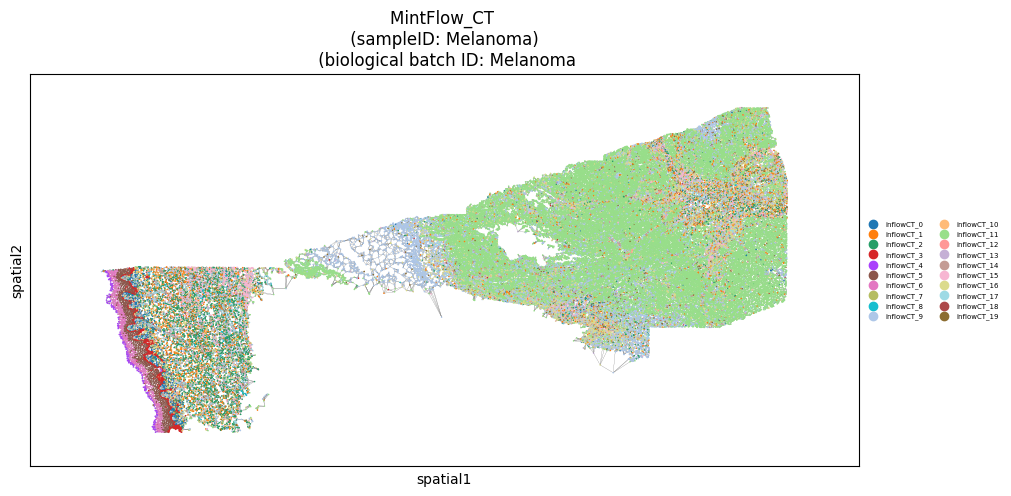

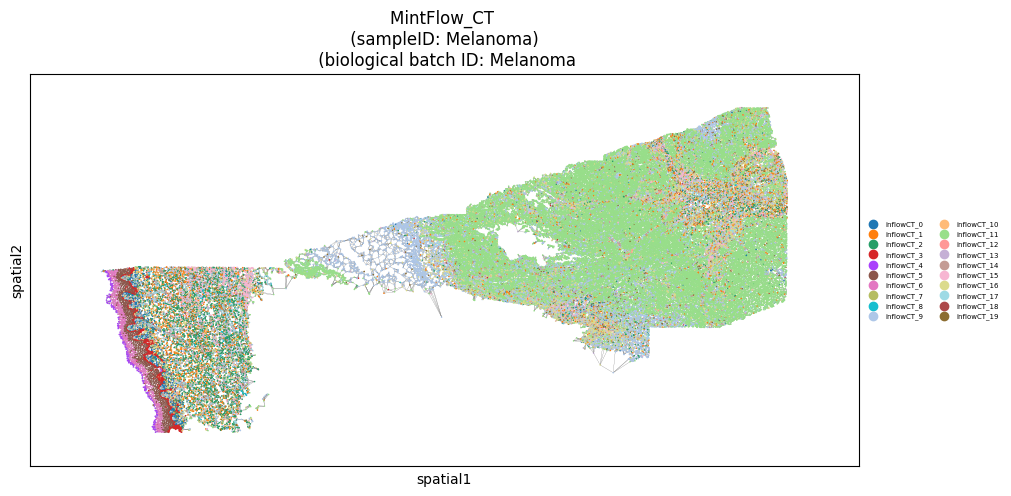





The provided cell types are aggregated/mapped to mintflow cell types as follow:
{'F1: Superficial': 'inflowCT_0',
 'F6: Myofibroblast': 'inflowCT_1',
 'F6: Myofibroblast inflammatory': 'inflowCT_2',
 'KCinflamm_basal': 'inflowCT_3',
 'KCinflamm_final': 'inflowCT_4',
 'KCinflamm_int': 'inflowCT_5',
 'KCinflamm_late': 'inflowCT_6',
 'LC': 'inflowCT_7',
 'LE': 'inflowCT_8',
 'Mac': 'inflowCT_9',
 'Mast cell': 'inflowCT_10',
 'Melanoma': 'inflowCT_11',
 'MigDC': 'inflowCT_12',
 'Nonspecific': 'inflowCT_13',
 'Pericyte': 'inflowCT_14',
 'Plasma cell': 'inflowCT_15',
 'T': 'inflowCT_16',
 'VE': 'inflowCT_17',
 'cDC1': 'inflowCT_18',
 'cDC2': 'inflowCT_19'}







The provided biological batch IDs are aggregated/mapped to mintflow batch IDs as follows
{'Melanoma': 'inflow_BatchID_0'}



One-hot encoded batch ID for each sample (tissue):
     sample Melanoma --> batch ID {0}
Customised neighbourloader sampler: computing some initial stats (max number of central nodes, etc) for each tissue.

  0%|          | 0/98749 [00:00<?, ?it/s]

  0%|          | 0/98749 [00:00<?, ?it/s]

    width_window=100 --> [maxnum_centralnodes:253.0,    worse-case batchsize:1528]


  0%|          | 0/98749 [00:00<?, ?it/s]

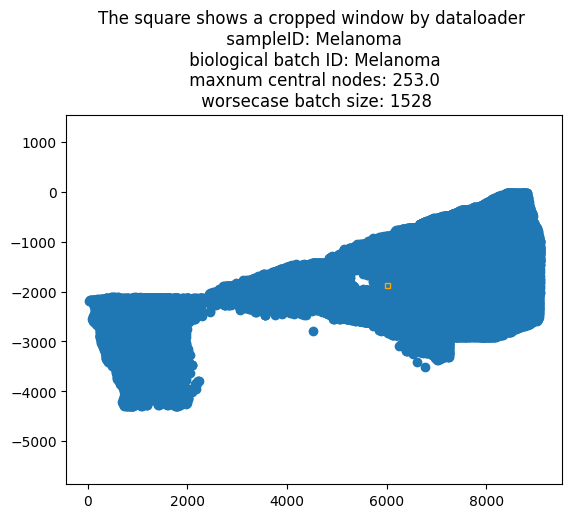

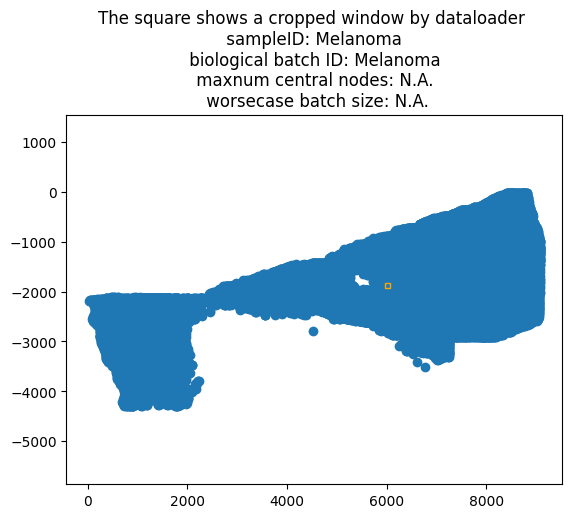

In [13]:
data_mintflow = mintflow.setup_data(dict_all4_configs=dict_all4_configs)

In [14]:
model = mintflow.setup_model(
    dict_all4_configs=dict_all4_configs,
    data_mintflow=data_mintflow
)



Device is set to cuda:0.




dict_pname_to_scaleandunweighted is set to:
{'sin': [0.1, True],
 'sout': [1.0, True],
 'x': [None, None],
 'xbar_int': [0.1, True],
 'xbar_spl': [0.1, True],
 'z': [1.0, True]}



{'CT': '1.ArchInsertionPoint', 'NCC': '3.ArchInsertionPoint'}

dict_qname_to_scaleandunweighted is set to: 
{'impanddisentgl_int': {'flag_unweighted': True, 'scale': 0.1},
 'impanddisentgl_spl': {'flag_unweighted': True, 'scale': 0.0},
 'sin': {'flag_unweighted': True, 'scale': 1.0},
 'sout': {'flag_unweighted': True, 'scale': 0.0},
 'varphi_enc_int': {'flag_unweighted': True, 'scale': 0.0},
 'varphi_enc_spl': {'flag_unweighted': True, 'scale': 0.0},
 'z': {'flag_unweighted': True, 'scale': 1.0}}


The way CTs/NCCs are fed to the 3rd encoder:
{'sin': [False, True], 'sout': [True, False], 'z': [True, False]}
MintFlow module was created on cuda:0.


In [15]:
trainer = mintflow.Trainer(
    dict_all4_configs=dict_all4_configs,
    model=model,
    data_mintflow=data_mintflow
)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: sb75 (sb75sanger) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 6. Train the Model
Set the variable `path_ouptput_files` below to the path where you want the training files (checkpoints etc) to be saved.

In [16]:
path_ouptput_files = "./NonGit/Outputs_TutorialNotebook1" #
# TODO:MODIFY: the path where checkpoints and other files are saved during training.

In [17]:
# Create the directory if it doesn't exist
os.makedirs(path_ouptput_files, exist_ok=True)

In [18]:
for index_epoch in tqdm(range(config_training['num_training_epochs']), desc='Training epoch'):
    '''
    IMPORTANT NOTE: To change the number of epochs, set `config_training['num_training_epochs']` in previous cells of this notebook
    and please refrain from changing the for loop here to, e.g., `for index_epoch in tqdm(range(10), ...)`.
    Because MintFlow's annealing module presumes that the number of epochs equals `config_training['num_training_epochs']`.
    ''' 
    
    # train for one epoch
    trainer.train_one_epoch()

    # get/save the predictions
    predictions = mintflow.predict(
        device=device,
        dict_all4_configs=dict_all4_configs,
        data_mintflow=data_mintflow,
        model=model,
        evalulate_on_sections="all",
    )
    with open(os.path.join(path_ouptput_files, "predictions_epoch_{}.pkl".format(index_epoch)), 'wb') as f:
        pickle.dump(
            predictions,
            f
        )

    # evaluate the model and save the evaluation result for this checkpoint
    df_evaluation_result = mintflow.evaluate_by_known_signalling_genes(
        device=device,
        dict_all4_configs=dict_all4_configs,
        data_mintflow=data_mintflow,
        model=model,
        evalulate_on_sections='all',
        optional_list_colvaltype_toadd=[['training_epoch', index_epoch, 'category']]
    )
    df_evaluation_result.to_pickle(
        os.path.join(
            path_ouptput_files,
            'df_evaluation_result_epoch_{}.pkl'.format(index_epoch)
        )
    )

    # save the checkpoint
    mintflow.dump_checkpoint(
        model=model,
        data_mintflow=data_mintflow,
        dict_all4_configs=dict_all4_configs,
        path_dump=os.path.join(path_ouptput_files, "checkpoint_epoch_{}.pt".format(index_epoch)),
    )    

Training epoch:   0%|          | 0/20 [00:00<?, ?it/s]

     Getting different embeddings to update the dual functions separately.


Tissue 0:   0%|          | 0/1655 [00:00<?, ?it/s]

Training the dual functions separately.:   0%|          | 0/200 [00:00<?, ?it/s]

MintFlow training epoch:   0%|          | 0/1539 [00:00<?, ?it/s]

...

MintFlow training epoch:   0%|          | 0/1539 [00:00<?, ?it/s]

/nfs/team361/sb75/mintflow/src/mintflow/generativemodel.py:869: UserWarning: The value argument must be within the support of the distribution
  ).log_prob(dict_qsamples['x_int'][:batch.batch_size])  # [b, num_genes]
/nfs/team361/sb75/mintflow/src/mintflow/generativemodel.py:893: UserWarning: The value argument must be within the support of the distribution
  ).log_prob(dict_qsamples['x_spl'][:batch.batch_size])  # [b, num_genes]


Evaluating on tissue section: 0:   0%|          | 0/1655 [00:00<?, ?it/s]

Evaluating on tissue section: 0:   0%|          | 0/1655 [00:00<?, ?it/s]

In the gene panel 370 genes were found in the list of known signalling genes.


## 7. Select the best checkpoint
To perform the analysis you can either pick the last checkpoint, or alternatively, you can pick the best checkpoint by inspecting the dumped `df_evaluation_result` objects. 
If the disentanglement is successful, the violinplots/boxplots that correspond to signalling genes should be skewed towards 1.0 (like the orange violin/box plots in the provided sample figures below) while for other genes they should be skewed towards 0.0 (like the blue violin/box plots in the provided sample figures below) 

Sample violin/box plots:
- a sample violinplot that shows succesful disentanglement: [(link to the figure)](https://github.com/Lotfollahi-lab/mintflow/blob/b9ffc2a1c7f66d5387b3037dd3f8e40521274cf3/docs/tutorials/notebooks/violin_plot.png)
- a sample boxplot that shows succesful disentanglement: [(link to the figure)](https://github.com/Lotfollahi-lab/mintflow/blob/b9ffc2a1c7f66d5387b3037dd3f8e40521274cf3/docs/tutorials/notebooks/box_plot.png)

To produce violin/box plots for a specific checkpoint, you can run the below cells.
To arrive at a metric, you can compute a discrepancy metric (e.g. [Wasserstein distance](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wasserstein_distance.html)) between the two groups specified in `is_among_signalling_genes`.

In [19]:
df_toinspect = pd.read_pickle(
    os.path.join(path_ouptput_files, 'df_evaluation_result_epoch_{}.pkl'.format(10))
)
# TODO:MODIFY: change `10` to the checkpoint index that you want to inspect

<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

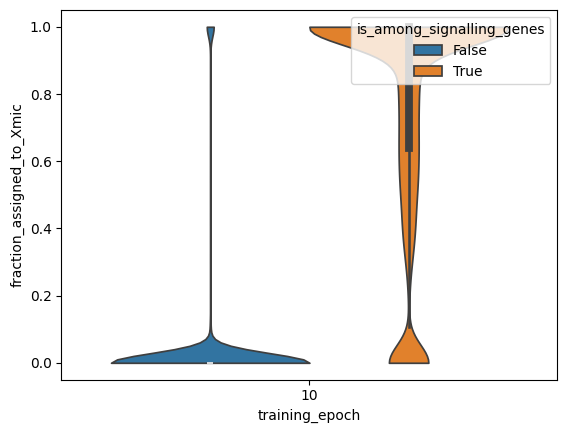

In [20]:
sns.violinplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes",
    cut=0
)

<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

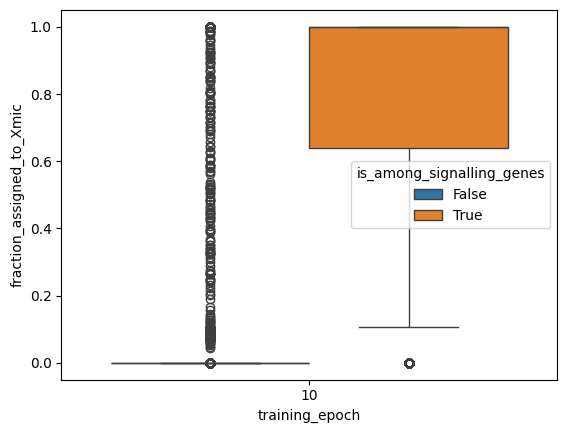

In [21]:
sns.boxplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes"
)

## 8. Use MintFlow predictions for analysis
Having selected the best (or a good) checkpoint, set the variable `index_selected_checkpoint` below and run the following cells.

In [22]:
index_selected_checkpoint = 19
# TODO:MODIFY: the index of the best (or a good) checkpoint that you selected. 

Load predictions for the selected checkpoint.

In [23]:
with open(os.path.join(path_ouptput_files, "predictions_epoch_{}.pkl".format(index_selected_checkpoint)), 'rb') as f:
    predictions_selected_checkpoint = pickle.load(f)

MintFlow predictions are available in `predictions_selected_checkpoint`. In particular, the intrinsic- and microenvironment-induced components of expression are available in 
- `predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xint']`
- `predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xmic']`

For example we can compute MintFlow's per-cell microenvironment signalling score as follows: 

In [24]:
Xint = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xint']
Xmic = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xmic']

In [25]:
MintFlow_microenvironment_signalling_score = Xmic.sum(1) / (Xint+Xmic).sum(1)